libraries

In [1]:
import sys
print(sys.executable)

c:\Users\yasha\OneDrive\Desktop\asl_project\asl_env\Scripts\python.exe


In [2]:
import numpy as np
import cv2
import os
import json
import mediapipe as mp
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt



In [3]:
dataset_path = r"C:\Users\yasha\OneDrive\Desktop\asl_project\ASL\asl_alphabet_train\asl_alphabet_train"

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

classes = sorted(os.listdir(dataset_path))
MAX_PER_CLASS = 500

X, y = [], []
failed = 0

for idx, cls in enumerate(classes):
    cls_folder = os.path.join(dataset_path, cls)
    files = os.listdir(cls_folder)[:MAX_PER_CLASS]
    count = 0
    for file in files:
        img_path = os.path.join(cls_folder, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = hands.process(rgb)
        if result.multi_hand_landmarks:
            landmarks = result.multi_hand_landmarks[0]
            coords = []
            for lm in landmarks.landmark:
                coords.extend([lm.x, lm.y, lm.z])
            X.append(coords)
            y.append(idx)
            count += 1
        else:
            failed += 1
    print(f"Done: {cls} — {count} images")

X = np.array(X)
y = np.array(y)
print(f"\nTotal: {len(X)} samples")
print(f"Failed: {failed}")

Done: A — 454 images
Done: B — 438 images
Done: C — 489 images
Done: D — 494 images
Done: E — 458 images
Done: F — 493 images
Done: G — 475 images
Done: H — 478 images
Done: I — 469 images
Done: J — 446 images
Done: K — 498 images
Done: L — 436 images
Done: M — 282 images
Done: N — 166 images
Done: O — 487 images
Done: P — 495 images
Done: Q — 469 images
Done: R — 481 images
Done: S — 500 images
Done: T — 462 images
Done: U — 455 images
Done: V — 452 images
Done: W — 417 images
Done: X — 450 images
Done: Y — 492 images
Done: Z — 495 images
Done: del — 377 images
Done: nothing — 0 images
Done: space — 394 images

Total: 12502 samples
Failed: 1998


In [ ]:
y_encoded = to_categorical(y, num_classes=len(classes))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,                      # Split + Classes save
    shuffle=True
)

with open(r'C:\Users\yasha\OneDrive\Desktop\asl_project\classes.json', 'w') as f:
    json.dump(classes, f)

print(f"Training: {X_train.shape}")
print(f"Testing:  {X_test.shape}")
print("Classes saved!")

Training: (10001, 63)
Testing:  (2501, 63)
Classes saved!


In [5]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(63,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               16384     
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [6]:
save_path = r'C:\Users\yasha\OneDrive\Desktop\asl_project\asl_landmark_model.h5'

checkpoint = ModelCheckpoint(
    save_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stop],
    verbose=1
)

print(f"\nBest val_accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/50
309/313 [============================>.] - ETA: 0s - loss: 1.5176 - accuracy: 0.5623
Epoch 1: val_accuracy improved from -inf to 0.57657, saving model to C:\Users\yasha\OneDrive\Desktop\asl_project\asl_landmark_model.h5
313/313 [==============================] - 4s 5ms/step - loss: 1.5054 - accuracy: 0.5660 - val_loss: 1.4767 - val_accuracy: 0.5766
Epoch 2/50
 32/313 [==>...........................] - ETA: 0s - loss: 0.5826 - accuracy: 0.8203

c:\Users\yasha\OneDrive\Desktop\asl_project\asl_env\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - ETA: 0s - loss: 0.4403 - accuracy: 0.8672
Epoch 2: val_accuracy improved from 0.57657 to 0.91923, saving model to C:\Users\yasha\OneDrive\Desktop\asl_project\asl_landmark_model.h5
313/313 [==============================] - 1s 5ms/step - loss: 0.4403 - accuracy: 0.8672 - val_loss: 0.2566 - val_accuracy: 0.9192
Epoch 3/50
312/313 [============================>.] - ETA: 0s - loss: 0.3280 - accuracy: 0.8976
Epoch 3: val_accuracy improved from 0.91923 to 0.93123, saving model to C:\Users\yasha\OneDrive\Desktop\asl_project\asl_landmark_model.h5
313/313 [==============================] - 1s 4ms/step - loss: 0.3279 - accuracy: 0.8976 - val_loss: 0.2797 - val_accuracy: 0.9312
Epoch 4/50
305/313 [============================>.] - ETA: 0s - loss: 0.3115 - accuracy: 0.9041
Epoch 4: val_accuracy did not improve from 0.93123
313/313 [==============================] - 1s 4ms/step - loss: 0.3127 - accuracy: 0.9041 - val_loss: 0.3435 - val_accuracy: 0.8836
Epo

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)


present_classes = sorted(set(y_true_classes))
present_names = [classes[i] for i in present_classes]

print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    labels=present_classes,
    target_names=present_names
))

79/79 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           A       0.99      1.00      0.99        98
           B       1.00      1.00      1.00        84
           C       0.99      1.00      0.99        99
           D       1.00      0.98      0.99       102
           E       0.97      1.00      0.98        89
           F       1.00      1.00      1.00       103
           G       0.99      1.00      0.99        95
           H       1.00      0.99      1.00       104
           I       1.00      0.98      0.99        96
           J       1.00      0.95      0.97        93
           K       0.99      1.00      0.99        98
           L       1.00      0.97      0.99       103
           M       0.95      1.00      0.98        59
           N       1.00      0.91      0.96        35
           O       0.99      1.00      0.99        96
           P       1.00      1.00      1.00        88
           Q       0.98     

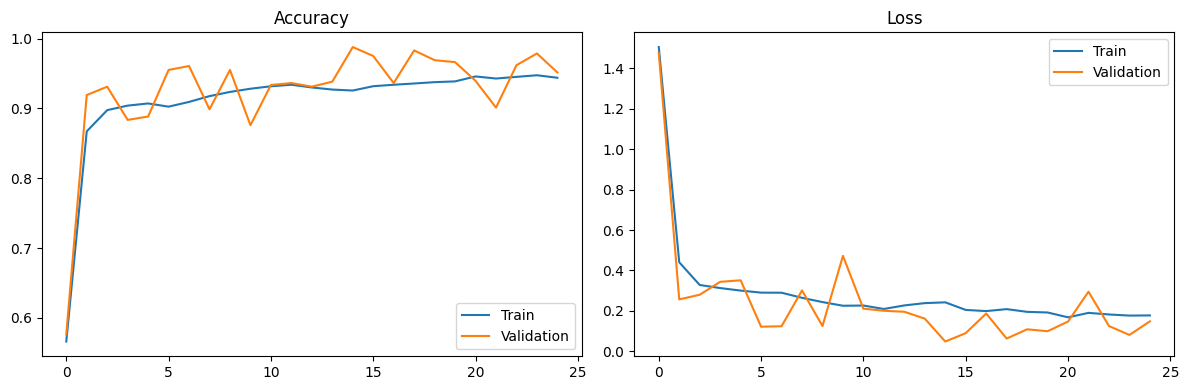

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
code = '''
# -*- coding: utf-8 -*-
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import json
import mediapipe as mp
import time

model = load_model(r"C:\\Users\\yasha\\OneDrive\\Desktop\\asl_project\\asl_landmark_model.h5")
with open(r"C:\\Users\\yasha\\OneDrive\\Desktop\\asl_project\\classes.json", "r") as f:
    classes = json.load(f)

print("Model loaded!")
print("=" * 50)
print("CONTROLS:")
print("  SPACE sign  = add space between words")
print("  DEL sign    = delete last letter")
print("  Q key       = quit")
print("=" * 50)

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

cap = cv2.VideoCapture(0)

pred_history = []
SMOOTH = 7
last_added = ""
last_add_time = 0
ADD_DELAY = 2        # 2 sec hold karo letter add karne ke liye

sentence = []        # sentence ke letters yahan store honge
hold_start = {}      # kab se hold kar raha hai

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    h, w, _ = frame.shape
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    current_time = time.time()

    if result.multi_hand_landmarks:
        for hand_landmarks in result.multi_hand_landmarks:

            mp_draw.draw_landmarks(
                frame, hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_draw.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=4),
                mp_draw.DrawingSpec(color=(255, 0, 0), thickness=2)
            )

            coords = []
            for lm in hand_landmarks.landmark:
                coords.extend([lm.x, lm.y, lm.z])
            coords = np.array(coords).reshape(1, -1)

            prediction = model.predict(coords, verbose=0)
            predicted_idx = np.argmax(prediction)

            pred_history.append(predicted_idx)
            if len(pred_history) > SMOOTH:
                pred_history.pop(0)

            smooth_idx = max(set(pred_history), key=pred_history.count)
            smooth_class = classes[smooth_idx]
            smooth_conf = prediction[0][smooth_idx] * 100

            # Hold timer — kitna time se same letter dikh raha hai
            if smooth_class not in hold_start:
                hold_start = {smooth_class: current_time}
            
            hold_duration = current_time - hold_start.get(smooth_class, current_time)
            time_left = max(0, ADD_DELAY - hold_duration)

            # Letter add karo jab 2 sec hold ho
            if hold_duration >= ADD_DELAY and smooth_conf > 70:
                if smooth_class != last_added or current_time - last_add_time >= ADD_DELAY:
                    
                    if smooth_class == "space":
                        sentence.append(" ")
                        print(f"[SPACE added]")
                    elif smooth_class == "del":
                        if sentence:
                            removed = sentence.pop()
                            print(f"[Deleted: {removed}]")
                    else:
                        sentence.append(smooth_class)
                        print(f"Letter added: {smooth_class}")

                    full_sentence = "".join(sentence)
                    print(f"Sentence: {full_sentence}")
                    print("-" * 40)

                    last_added = smooth_class
                    last_add_time = current_time
                    hold_start = {}

            # Bounding box
            x_list = [lm.x * w for lm in hand_landmarks.landmark]
            y_list = [lm.y * h for lm in hand_landmarks.landmark]
            x1 = max(0, int(min(x_list)) - 30)
            y1 = max(0, int(min(y_list)) - 30)
            x2 = min(w, int(max(x_list)) + 30)
            y2 = min(h, int(max(y_list)) + 30)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 2)

            # Hold progress bar
            progress = min(1.0, hold_duration / ADD_DELAY)
            bar_width = int(progress * (x2 - x1))
            cv2.rectangle(frame, (x1, y2 + 5), (x2, y2 + 20), (50, 50, 50), -1)
            cv2.rectangle(frame, (x1, y2 + 5), (x1 + bar_width, y2 + 20), (0, 255, 0), -1)
            cv2.putText(frame, f"Hold: {hold_duration:.1f}s / {ADD_DELAY}s",
                        (x1, y2 + 35),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150, 150, 150), 1)

            # Current letter
            color = (0, 255, 0) if smooth_conf > 70 else (0, 165, 255)
            cv2.putText(frame, f"{smooth_class}  {smooth_conf:.1f}%",
                        (x1, y1 - 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)

            # Top 3
            top3_idx = np.argsort(prediction[0])[::-1][:3]
            for i, idx in enumerate(top3_idx):
                conf = prediction[0][idx] * 100
                cv2.putText(frame, f"{i+1}. {classes[idx]}: {conf:.1f}%",
                            (10, 160 + i * 28),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.65, (200, 200, 200), 2)

    else:
        pred_history.clear()
        hold_start = {}
        cv2.putText(frame, "Show your hand!", (30, 80),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # Sentence display on screen
    full_sentence = "".join(sentence)

    # Background box for sentence
    cv2.rectangle(frame, (0, 0), (w, 55), (30, 30, 30), -1)
    cv2.putText(frame, f"Sentence: {full_sentence}",
                (10, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

    # Controls info
    cv2.rectangle(frame, (0, h - 30), (w, h), (30, 30, 30), -1)
    cv2.putText(frame, "SPACE=space  DEL=delete  Q=quit",
                (10, h - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (150, 150, 150), 1)

    cv2.imshow("ASL Sentence Builder", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        print("=" * 50)
        print(f"Final sentence: {full_sentence}")
        print("=" * 50)
        break

cap.release()
cv2.destroyAllWindows()
'''

path = r'C:\Users\yasha\OneDrive\Desktop\asl_project\webcam_live.py'
with open(path, 'w', encoding='utf-8') as f:
    f.write(code)

print("File saved!")

File saved!


In [ ]:
#python webcam_live.py